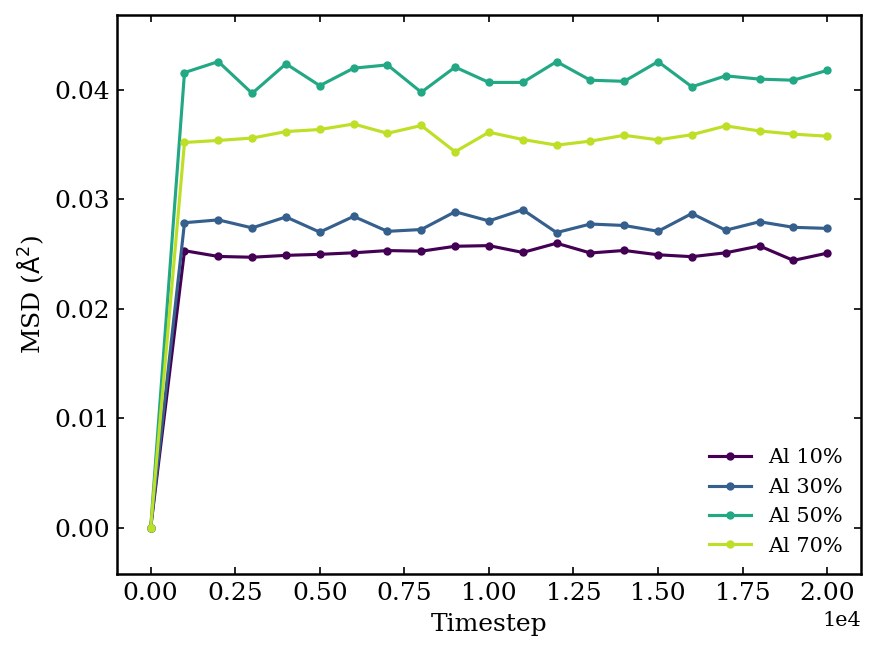

In [3]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Find all MSD files (e.g., Al10_MSD_300K.dat)
# ------------------------------------------------------------
files = glob.glob("Al*_MSD_300K.dat")

# Extract Al composition from filename
def extract_al(filepath):
    match = re.search(r"Al(\d+)_MSD_300K", os.path.basename(filepath))
    return int(match.group(1)) if match else 0

# Sort files by Al composition
files.sort(key=extract_al)

if not files:
    raise FileNotFoundError("No files matching 'Al*_MSD_300K.dat' were found.")

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

fig, ax = plt.subplots(figsize=(6, 4.5), dpi=150)

# Colour map
colors = plt.cm.viridis(np.linspace(0, 0.9, len(files)))

# ------------------------------------------------------------
# Plot each MSD file
# ------------------------------------------------------------
for filepath, color in zip(files, colors):

    data = np.loadtxt(filepath, comments="#")

    # Column 1 = timestep
    # Column 2 = MSD
    x = data[:, 0]
    y = data[:, 1]

    al = extract_al(filepath)

    ax.plot(
        x,
        y,
        color=color,
        linewidth=1.5,
        marker="o",
        markersize=3,
        linestyle="-",
        label=f"Al {al}%"
    )

# ------------------------------------------------------------
# Axes labels
# ------------------------------------------------------------
ax.set_xlabel("Timestep")
ax.set_ylabel(r"MSD ($\mathrm{\AA}^2$)")

# Scientific notation on x-axis (same as original script)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax.xaxis.get_offset_text().set_fontsize(10)

# Margins
ax.margins(x=0.05, y=0.10)

# Legend
ax.legend(frameon=False, fontsize=10)

# Tight layout
fig.tight_layout()

# Save figures
fig.savefig("MSD_all_300K.png", dpi=300, bbox_inches="tight")
#fig.savefig("MSD_all_300K.pdf", bbox_inches="tight")

plt.show()